<a href="https://colab.research.google.com/github/Raimbek-pro/ml-projects/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install tensorflow Pillow

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16

# Load the VGG16 model with pre-trained ImageNet weights
vgg_model = VGG16(weights='imagenet')
vgg_model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Now, let's use the VGG16 model to predict the classes in the image you provided. We'll reuse the image preprocessing code we defined earlier.

In [ ]:
# Returns a list of numpy arrays (weights and biases for all layers)
all_weights = vgg_model.get_weights()

print(len(all_weights))   # number of weight tensors
print(all_weights[0].shape)  # shape of the first tensor
print(all_weights[0])       # actual numbers


32
(3, 3, 3, 64)
[[[[ 4.29470569e-01  1.17273867e-01  3.40129584e-02 ... -1.32241577e-01
    -5.33475243e-02  7.57738389e-03]
   [ 5.50379455e-01  2.08774377e-02  9.88311544e-02 ... -8.48205537e-02
    -5.11389151e-02  3.74943428e-02]
   [ 4.80015397e-01 -1.72696680e-01  3.75577137e-02 ... -1.27135560e-01
    -5.02991639e-02  3.48965675e-02]]

  [[ 3.73466998e-01  1.62062630e-01  1.70863140e-03 ... -1.48207128e-01
    -2.35300660e-01 -6.30356818e-02]
   [ 4.40074533e-01  4.73412387e-02  5.13819456e-02 ... -9.88498852e-02
    -2.96195745e-01 -7.04357103e-02]
   [ 4.08547401e-01 -1.70375049e-01 -4.96297423e-03 ... -1.22360572e-01
    -2.76450396e-01 -3.90796512e-02]]

  [[-6.13601133e-02  1.35693997e-01 -1.15694344e-01 ... -1.40158370e-01
    -3.77666801e-01 -3.00509870e-01]
   [-8.13870355e-02  4.18543853e-02 -1.01763301e-01 ... -9.43124294e-02
    -5.05662560e-01 -3.83694321e-01]
   [-6.51455522e-02 -1.54351532e-01 -1.38038069e-01 ... -1.29404560e-01
    -4.62243795e-01 -3.23985279e-01

Using image: /content/images_cat.jpg


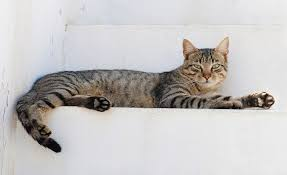

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Predicted Classes and Probabilities (VGG16):
1: bathtub (0.29)
2: tabby (0.26)
3: tub (0.17)
4: Egyptian_cat (0.11)
5: washbasin (0.06)


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_input_vgg16
from tensorflow.keras.applications.vgg16 import decode_predictions as decode_predictions_vgg16
import numpy as np
import PIL.Image
from IPython.display import display, Image

# Define the preprocess_image function for VGG16
def preprocess_image_vgg16(image_path):
    """
    Loads and preprocesses an image for VGG16 model.

    Args:
        image_path (str): The path to the image file.

    Returns:
        np.ndarray: The preprocessed image array.
    """
    img = PIL.Image.open(image_path)
    img = img.resize((224, 224))  # VGG16 also expects 224x224
    img_array = np.array(img)
    # Add a batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Preprocess input specifically for VGG16
    img_array = preprocess_input_vgg16(img_array)
    return img_array

image_path = '/content/images_cat.jpg'

# Display the image
print(f"Using image: {image_path}")
display(Image(image_path))

# Preprocess the image using the VGG16 preprocessor
preprocessed_img_vgg16 = preprocess_image_vgg16(image_path)

# Perform prediction on the image using the VGG16 model
predictions_vgg16 = vgg_model.predict(preprocessed_img_vgg16)

# Decode and display the predictions
decoded_predictions_vgg16 = decode_predictions_vgg16(predictions_vgg16, top=5)[0]

print("\nPredicted Classes and Probabilities (VGG16):")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions_vgg16):
    print(f"{i + 1}: {label} ({score:.2f})")

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(weights='imagenet')
model.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

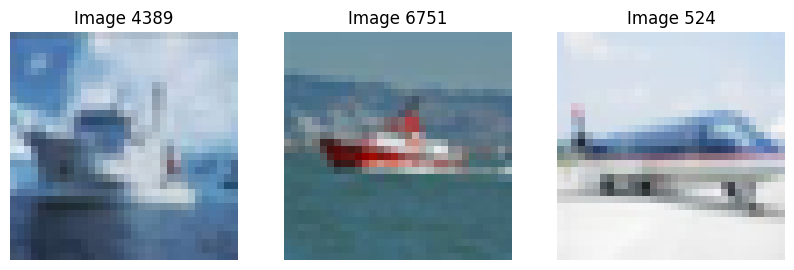

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step

Predictions for Sample Images:

Image 4389 Predicted Classes and Probabilities:
1: rotisserie (0.14)
2: gong (0.05)
3: space_shuttle (0.04)
4: maraca (0.02)
5: eggnog (0.02)

Image 6751 Predicted Classes and Probabilities:
1: black_grouse (0.09)
2: letter_opener (0.08)
3: ski (0.06)
4: ballpoint (0.05)
5: platypus (0.05)

Image 524 Predicted Classes and Probabilities:
1: matchstick (0.31)
2: projectile (0.08)
3: torch (0.07)
4: lighter (0.06)
5: ballpoint (0.05)


In [ ]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image # Import Image from PIL
from tensorflow.keras.applications.resnet50 import decode_predictions # Import decode_predictions here

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Select a few DIFFERENT images from the test set (e.g., images from index 10 to 12)
num_images_to_show = 3
# Select random images from the test set
random_indices = np.random.choice(len(x_test), num_images_to_show, replace=False)
sample_images = x_test[random_indices]
sample_labels = y_test[random_indices]

# Display the sample images
plt.figure(figsize=(10, 5))
for i in range(num_images_to_show):
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"Image {random_indices[i]}") # Adjust title to reflect the index
    plt.axis('off')
plt.show()

# Preprocess the sample images for the ResNet50 model
preprocessed_sample_images = []
for img in sample_images:
    # ResNet50 expects 224x224, CIFAR-10 is 32x32, so we need to resize
    img_pil = Image.fromarray(img) # Use PIL.Image.fromarray
    img_resized = img_pil.resize((224, 224))
    preprocessed_sample_images.append(np.array(img_resized))

preprocessed_sample_images = np.array(preprocessed_sample_images)

# Perform predictions on the preprocessed sample images
predictions = model.predict(preprocessed_sample_images)

# Decode and display the predictions for each image
print("\nPredictions for Sample Images:")
for i in range(num_images_to_show):
    decoded_predictions = decode_predictions(predictions[i].reshape(1, -1), top=5)[0]
    print(f"\nImage {random_indices[i]} Predicted Classes and Probabilities:") # Adjust title to reflect the index
    for j, (imagenet_id, label, score) in enumerate(decoded_predictions):
        print(f"{j + 1}: {label} ({score:.2f})")

Using image: /content/images_cat.jpg


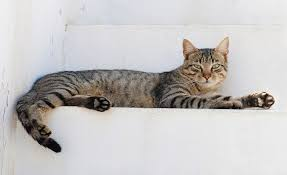

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicted Classes and Probabilities:
1: tabby (0.52)
2: tiger_cat (0.26)
3: Egyptian_cat (0.20)
4: tiger (0.01)
5: lynx (0.00)


In [ ]:
import numpy as np
import PIL.Image
from IPython.display import display, Image
from tensorflow.keras.applications.resnet50 import decode_predictions

# Define the preprocess_image function within this cell
def preprocess_image(image_path):
    """
    Loads and preprocesses an image for ResNet50 model.

    Args:
        image_path (str): The path to the image file.

    Returns:
        np.ndarray: The preprocessed image array.
    """
    img = PIL.Image.open(image_path) # Use PIL.Image.open
    img = img.resize((224, 224))  # Resize to ResNet50 input size
    img_array = np.array(img)
    # Add a batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

image_path = '/content/images_cat.jpg'

# Display the image
print(f"Using image: {image_path}")
display(Image(image_path))

# Preprocess the image
preprocessed_img = preprocess_image(image_path)

# Perform prediction on the image
predictions = model.predict(preprocessed_img)

# Decode and display the predictions
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("\nPredicted Classes and Probabilities:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

In [ ]:
from tensorflow.keras.applications import VGG16

# Create the VGG16 model architecture
model = VGG16(weights=None)  # no weights yet

# Load pretrained weights from the file
model.load_weights("vgg16_weights_tf_dim_ordering_tf_kernels.h5")

# Inspect weights
for layer in model.layers:
    print(f"Layer: {layer.name}")
    for w in layer.get_weights():
        print(w.shape)
        print(w)   # actual numbers


OSError: Unable to synchronously open file (file signature not found)